# Offensive IT-Tester — EDA, Baseline Model, XAI & Model Card

**Course:** Responsible AI & Data Ethics
**This single notebook** carries the full arc the brief asks for: profound data
analysis → a baseline model → explainability → risk → limitations → a pseudo
model-card at the end. It runs top-to-bottom with no manual steps.

**Provenance.** Sections 1–5 are the group's **week-1 EDA**, preserved. Section 3
is extended with context *normalisation* (the bucketing that unblocks selection),
and Section 4's naive matrix is followed by its repaired version. Sections 6–11
are the **week-2** model and responsible-AI evaluation.

### What the model is — and is not
- **Is:** a classifier `payload string → attack_class` over five classes
  (`sqli, xss, csrf, cmdi, ssrf`).
- **Is not:** a *vulnerability* detector. Training data is attack-payloads-only —
  the **no-benign-class gap** — so it cannot say "this is benign". This caveat
  recurs and is demonstrated live in Section 10.
- **Role:** a soft prior for Layer-3 selection / Layer-6 triage, always paired
  with a probability, an explanation, and human review — never a bare verdict.

## 0. Setup

Loads via the repo's `config.paths` convention (as in week 1), with a fallback so
the notebook also runs standalone.

In [14]:
import re
import sys
from pathlib import Path
from itertools import combinations
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- load the cleaned dataset (week-1 convention first, then fallbacks) ------
df = None
try:
    root = Path.cwd().parent
    sys.path.insert(0, str(root))
    from config.paths import CLEAN
    df = pd.read_json(CLEAN / "payloads_clean.jsonl", lines=True)
    print(f"Loaded via config.paths from {CLEAN}")
except Exception as e:
    for p in [Path("data/cleaned/payloads_clean.jsonl"),
              Path("../data/cleaned/payloads_clean.jsonl"),
              Path("/mnt/user-data/uploads/payloads_clean.jsonl")]:
        if p.exists():
            df = pd.read_json(p, lines=True); print(f"Loaded via fallback {p}"); break
if df is None:
    raise FileNotFoundError("payloads_clean.jsonl not found.")

print(f"Total payloads: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded via config.paths from C:\Users\yuvra\Desktop\UNI\RADE\data\cleaned
Total payloads: 455
Columns: ['id', 'attack_class', 'payload', 'type', 'severity', 'context', 'description', 'example']


,id,attack_class,payload,type,severity,context,description,example
0,sqli-001,sqli,' OR '1'='1,tautology,high,Login form username input,Basic tautology-based SQL injection,SELECT * FROM users WHERE username = '' OR '1'='1' AND password = ''
1,sqli-002,sqli,"' UNION SELECT username, password FROM users--",union,high,Search input field,Union-based SQL injection to extract data,"SELECT name, description FROM products WHERE name = '' UNION SELECT username..."
2,sqli-003,sqli,'; WAITFOR DELAY '0:0:5'--,blind-time,medium,ID parameter in URL,Blind SQL injection with time delay,SELECT * FROM orders WHERE id = ''; WAITFOR DELAY '0:0:5'--
3,sqli-004,sqli,"' AND 1=CONVERT(int,@@version)--",error-based,medium,User ID input,Error-based SQL injection to reveal database version,"SELECT * FROM users WHERE id = '' AND 1=CONVERT(int,@@version)--"
4,sqli-005,sqli,' AND 1=1--,boolean-blind,medium,Search field,Boolean-based blind SQL injection,SELECT * FROM products WHERE name = '' AND 1=1--


## 1. Class distribution  *(week-1)*

Answers how well-armed the agent is per attack class. **Note the correction:** the
distribution must be read on `attack_class`, not `type` (which mixes whole classes
with SQLi/XSS sub-techniques). Both are printed so the difference is visible.

In [15]:
class_counts = df["type"].value_counts()
class_pct = (class_counts / len(df) * 100).round(1)

dist = pd.DataFrame({"count": class_counts, "percent": class_pct})
print(dist)


type_count = df['attack_class'].value_counts()
class_pct2 = (type_count / len(df) * 100).round(1)
count_2 = pd.DataFrame({"count": type_count, "percent": class_pct2})
print(count_2)

                   count  percent
type                             
CSRF                  95     20.9
Command Injection     88     19.3
SSRF                  85     18.7
reflected             54     11.9
stored                46     10.1
blind-time            33      7.3
tautology             17      3.7
boolean-blind         13      2.9
stacked-queries       11      2.4
union                  9      2.0
error-based            4      0.9
              count  percent
attack_class                
xss             100     22.0
csrf             95     20.9
cmdi             88     19.3
sqli             87     19.1
ssrf             85     18.7


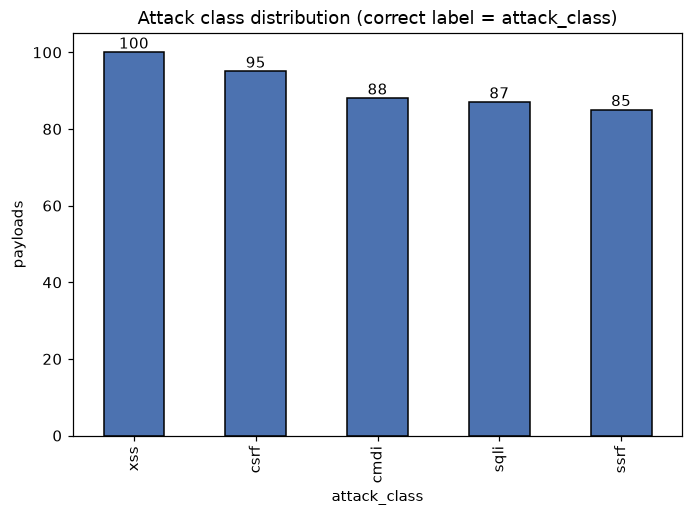

Imbalance ratio max/min: 1.18x  -> mild.


In [16]:
# Visual on the CORRECT label.
cc = df["attack_class"].value_counts()
ax = cc.plot(kind="bar", color="#4C72B0", edgecolor="black")
ax.set_title("Attack class distribution (correct label = attack_class)")
ax.set_ylabel("payloads")
for i, v in enumerate(cc): ax.text(i, v + 1, str(v), ha="center")
plt.tight_layout(); plt.show()
print(f"Imbalance ratio max/min: {cc.max()/cc.min():.2f}x  -> mild.")

## 2. Severity distribution  *(week-1)*

How much of the arsenal is high-risk — i.e. how hard the governance gate must
work — and which classes carry the dangerous payloads.

In [17]:
sev_counts = df["severity"].value_counts()
sev_pct = (sev_counts / len(df) * 100).round(1)

print(pd.DataFrame({"count": sev_counts, "percent": sev_pct}))

# How much of the arsenal is high-risk = how hard the gate works
high_risk = df["severity"].str.lower().isin(["high", "critical"]).sum()
print(f"\nHigh/critical payloads the gate must hold or escalate: "
      f"{high_risk} ({high_risk/len(df)*100:.1f}%)")

# Which classes carry the dangerous payloads
print("\nSeverity by attack class:")
print(pd.crosstab(df["attack_class"], df["severity"]))

          count  percent
severity                
high        242     53.2
medium      138     30.3
critical     63     13.8
low          12      2.6

High/critical payloads the gate must hold or escalate: 305 (67.0%)

Severity by attack class:
severity      critical  high  low  medium
attack_class                             
cmdi                19    40    0      29
csrf                12    55    4      24
sqli                11    18    0      58
ssrf                21    29    8      27
xss                  0   100    0       0


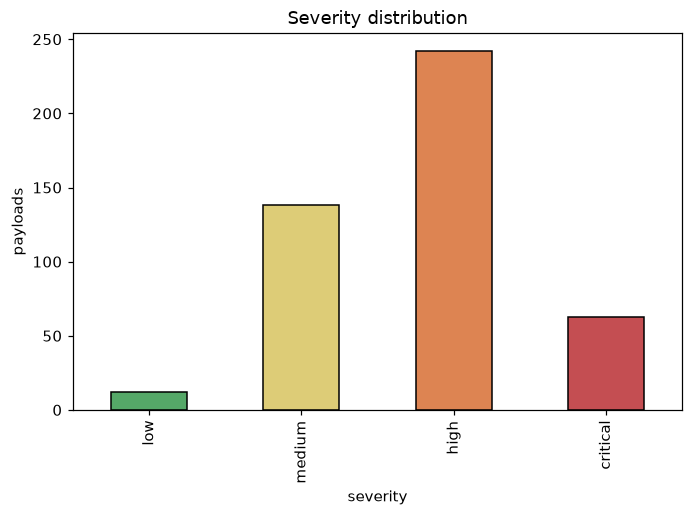

In [18]:
sev_order = ["low", "medium", "high", "critical"]
sev = df["severity"].value_counts().reindex(sev_order).fillna(0).astype(int)
ax = sev.plot(kind="bar", color=["#55A868","#DDCC77","#DD8452","#C44E52"],
              edgecolor="black")
ax.set_title("Severity distribution"); ax.set_ylabel("payloads")
plt.tight_layout(); plt.show()

## 3. Context analysis  *(week-1)*

Where payloads apply — the basis for selection. The week-1 finding: `context` is
high-cardinality free text with many thinly-covered values.

In [19]:
ctx_counts = df["context"].value_counts()
print("Payloads available per context (injection-point type):")
print(ctx_counts)

# Contexts with very few payloads = injection points the agent can find
# but barely test
thin = ctx_counts[ctx_counts < 5]
if not thin.empty:
    print("\nThinly-covered contexts:")
    print(thin)

Payloads available per context (injection-point type):
context
URL parameter                              55
Malicious webpage                          46
User input field                           43
Search input                               25
User input                                 20
                                           ..
Decode and execute base64 payload           1
Use newline as command separator            1
Obfuscated PowerShell encoded command       1
Nested command substitution with quotes     1
Indirect command execution via env var      1
Name: count, Length: 230, dtype: int64

Thinly-covered contexts:
context
Search field                               3
Execute whoami command                     3
Login input                                2
HTTP header injection                      2
Nested command substitution                2
                                          ..
Decode and execute base64 payload          1
Use newline as command separator           

### 3.1 Context normalisation → injection-point buckets  *(week-2 extension)*

The raw column has **230 distinct values** that mean only a handful of things.
Selection cannot use it until it is normalised. We map the 230 strings to a small
vocabulary aligned with the Layer-2 recon taxonomy (`form_field`, `url_param`,
`http_header`, `cookie`, …). Rules are ordered — first match wins — so
class-specific signals come before generic ones.

In [20]:
BUCKET_RULES = [
    ("login_form",     r"login|sign[\s-]?in|username|password|\bauth"),
    ("search_field",   r"search"),
    ("ssrf_target",    r"internal|metadata|localhost service|network device|redis|"
                       r"memcached|\bftp\b|\bsmb\b|mysql|smtp|snmp|\bec2|\baws|gcp|"
                       r"azure|cloud|instance|gopher|ldap|\bnfs\b|imap|pop3|mqtt|"
                       r"websocket|protocol|scheme|magnet|bitcoin|traversal|smuggling"),
    ("command_exec",   r"command|shell|whoami|curl|netcat|\bnc\b|shadow|environment|"
                       r"director|process|reverse|exfiltrat|substitution|\bread |"
                       r"write to|print |\bexec|passwd"),
    ("script_context", r"script|\beval|innerhtml|\bsvg|\bdom\b|element creation|"
                       r"concatenat|obfuscat|encoded|base64|\bhex|\bimg|onerror|"
                       r"iframe|\bcss|animation|expression"),
    ("attacker_page",  r"malicious (web)?page|attacker|forged|external site|"
                       r"interaction triggered"),
    ("account_settings", r"setting|management|subscription|account|transfer|banking|"
                       r"payment|admin|notification|webhook|ssh key|firewall|\bdns\b|"
                       r"forwarding|iot"),
    ("comment_field",  r"comment|feedback|message|review|\bpost|forum|\bbio|guestbook"),
    ("url_param",      r"\burl\b|parameter|query string|\bid\b|get param|querystring|"
                       r"redirect|method test"),
    ("http_header",    r"header|user-?agent|referer|x-forwarded|host header"),
    ("cookie",         r"cookie|session"),
    ("file_upload",    r"upload|file ?name|attachment"),
    ("api_json",       r"\bapi\b|json|rest|graphql|xml|soap|endpoint|fetch"),
    ("profile_form",   r"profile|registration|contact|newsletter|calendar|"
                       r"email service|social media|mailing"),
    ("form_field",     r"form|input|field|text ?area|checkout"),
]

def bucket_context(text: str) -> str:
    t = str(text).lower()
    for name, pattern in BUCKET_RULES:
        if re.search(pattern, t):
            return name
    return "other"

df["context_bucket"] = df["context"].apply(bucket_context)
print(f"Context cardinality: {df['context'].nunique()} free-text "
      f"-> {df['context_bucket'].nunique()} buckets\n")
print(df["context_bucket"].value_counts())
other_share = (df["context_bucket"] == "other").mean() * 100
print(f"\nUnbucketed ('other'): {other_share:.1f}%  (residual = long-tail SSRF "
      "protocols/services).")

Context cardinality: 230 free-text -> 14 buckets

context_bucket
url_param           85
command_exec        71
form_field          65
attacker_page       47
ssrf_target         45
search_field        30
script_context      28
other               25
account_settings    21
login_form          18
comment_field        8
api_json             5
profile_form         4
http_header          3
Name: count, dtype: int64

Unbucketed ('other'): 5.5%  (residual = long-tail SSRF protocols/services).


**Finding — `context` means different things per class.** Bucketing reveals
the column is not consistently an *injection point*: `sqli`/`xss` name the door,
`cmdi` names the **command action** ("Read shadow file"), `csrf` names the
**target page** ("Malicious webpage"), `ssrf` names the **internal target** ("AWS
metadata"). So selection logic must be **class-aware** — a single flat context
vocabulary cannot serve all five classes. Recorded for the risk log and model
card.

In [21]:
dominant = (df.groupby("attack_class")["context_bucket"]
              .agg(lambda s: s.value_counts().index[0]))
print("Most common context bucket per class (evidence of class-dependent meaning):")
print(dominant.to_string())

# Persist the normalised dataset for downstream layers.
try:
    from config.paths import PROCESSED
    PROCESSED.mkdir(parents=True, exist_ok=True)
    out = PROCESSED / "payloads_bucketed.jsonl"
except Exception:
    out = Path("data/processed/payloads_bucketed.jsonl"); out.parent.mkdir(parents=True, exist_ok=True)
df.to_json(out, orient="records", lines=True)
print(f"\nWrote {out}")

Most common context bucket per class (evidence of class-dependent meaning):
attack_class
cmdi     command_exec
csrf    attacker_page
sqli     search_field
ssrf      ssrf_target
xss         url_param

Wrote C:\Users\yuvra\Desktop\UNI\RADE\data\processed\payloads_bucketed.jsonl


## 4. Coverage matrix  *(week-1 naive → week-2 repaired)*

First the week-1 matrix on `type × context`. With 230 context values it is huge and
mostly empty, so its "blind spot" count is not meaningful — which is exactly the
motivation for the normalisation above.

In [22]:
coverage = pd.crosstab(df["type"], df["context"])
print("Coverage matrix (rows = attack class, cols = context):")
print(coverage)

# Explicitly list the combinations the scanner CANNOT meaningfully test
blind_spots = [(t, c) for t in coverage.index for c in coverage.columns
               if coverage.loc[t, c] == 0]
print(f"\nBlind spots (zero payloads): {len(blind_spots)}")
for t, c in blind_spots:
    print(f"  - {t} in {c}")

Coverage matrix (rows = attack class, cols = context):
context            AWS EC2 instance metadata  Access Docker API  \
type                                                              
CSRF                                       0                  0   
Command Injection                          0                  0   
SSRF                                       1                  1   
blind-time                                 0                  0   
boolean-blind                              0                  0   
error-based                                0                  0   
reflected                                  0                  0   
stacked-queries                            0                  0   
stored                                     0                  0   
tautology                                  0                  0   
union                                      0                  0   

context            Access Elasticsearch  Access IMAP mail server  \
type 

### 4.1 Repaired coverage — `attack_class × context_bucket`  *(week-2)*

On the normalised buckets the matrix is small and honest. Zero cells are real
blind spots and feed the fairness deliverable.

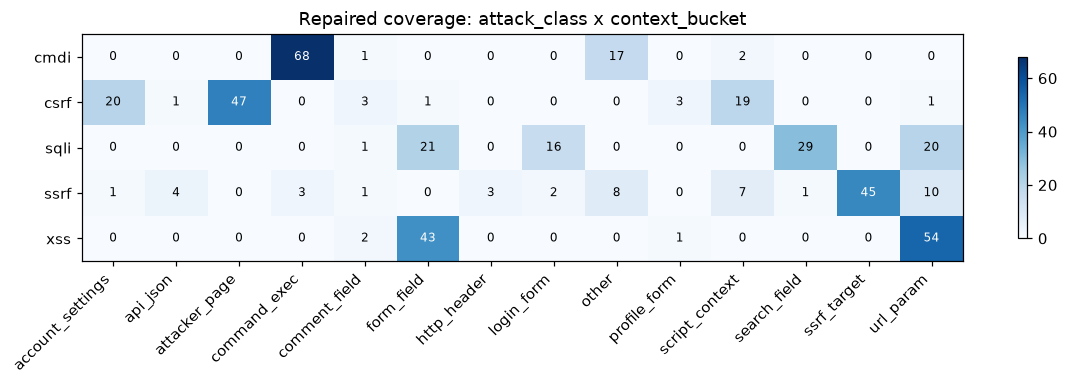

Blind spots (zero payloads): 38 of 70 cells


In [23]:
cov = pd.crosstab(df["attack_class"], df["context_bucket"])
fig, ax = plt.subplots(figsize=(11, 3.6))
im = ax.imshow(cov.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(cov.columns))); ax.set_xticklabels(cov.columns, rotation=45, ha="right")
ax.set_yticks(range(len(cov.index))); ax.set_yticklabels(cov.index)
for i in range(cov.shape[0]):
    for j in range(cov.shape[1]):
        v = cov.values[i, j]
        ax.text(j, i, v, ha="center", va="center",
                color="white" if v > cov.values.max()/2 else "black", fontsize=8)
ax.set_title("Repaired coverage: attack_class x context_bucket")
plt.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout(); plt.show()
blind = [(r, c) for r in cov.index for c in cov.columns if cov.loc[r, c] == 0]
print(f"Blind spots (zero payloads): {len(blind)} of {cov.size} cells")

## 5. Destructive-payload detection  *(week-1)*

Scan raw payload text to validate severity labels and seed the governance-gate
rules. Key finding: some destructive payloads are **not** labelled high/critical,
so the gate cannot trust severity labels alone. (Caveat retained: the
`ssrf_metadata` pattern is deliberately broad and also flags ordinary localhost
SSRF probes — split "reaches internal host" from "destroys data" when turning
these into gate rules.)

In [24]:
# Patterns that indicate a payload proves the vuln by causing real harm
destructive_patterns = {
    "sql_destructive":  r"\b(DROP|DELETE|TRUNCATE|ALTER)\s+(TABLE|DATABASE)\b",
    "shell_destructive": r"rm\s+-rf|mkfs|>\s*/dev/|:\(\)\{",
    "ssrf_metadata":    r"169\.254\.169\.254|metadata\.google|localhost|127\.0\.0\.1|0\.0\.0\.0",
    "file_write":       r">\s*/|dd\s+if=|chmod\s+777",
}

def flag_destructive(payload):
    hits = [name for name, pat in destructive_patterns.items()
            if re.search(pat, str(payload), re.IGNORECASE)]
    return hits

df["destructive_flags"] = df["payload"].apply(flag_destructive)
df["is_destructive"] = df["destructive_flags"].apply(len) > 0

destructive = df[df["is_destructive"]]
print(f"Destructive payloads found: {len(destructive)}")
print(destructive[["type", "severity", "payload", "destructive_flags"]])

# Trust check: are destructive payloads actually labelled high/critical?
mislabelled = destructive[
    ~destructive["severity"].str.lower().isin(["high", "critical"])
]
print(f"\nDestructive but NOT labelled high/critical "
      f"(severity labels can't be trusted alone): {len(mislabelled)}")
print(mislabelled[["type", "severity", "payload"]])

Destructive payloads found: 64
                  type  severity  \
5      stacked-queries  critical   
60     stacked-queries  critical   
282               SSRF      high   
284               SSRF  critical   
285               SSRF  critical   
..                 ...       ...   
362               SSRF       low   
363               SSRF       low   
364               SSRF  critical   
365               SSRF  critical   
406  Command Injection    medium   

                                                        payload  \
5                                         '; DROP TABLE users--   
60                                     '; DROP TABLE sessions--   
282                                           http://127.0.0.1/   
284                    http://169.254.169.254/latest/meta-data/   
285         http://metadata.google.internal/computeMetadata/v1/   
..                                                          ...   
362                                  http://127.0.0.1/#fragment   


## 6. Payload shape — why character n-grams  *(week-2)*

The baseline uses **character** n-grams, not words: payloads are syntax and symbols
(`'`, `--`, `<script>`, `;`, `$()`), not English. Length and characteristic
substrings per class confirm this.

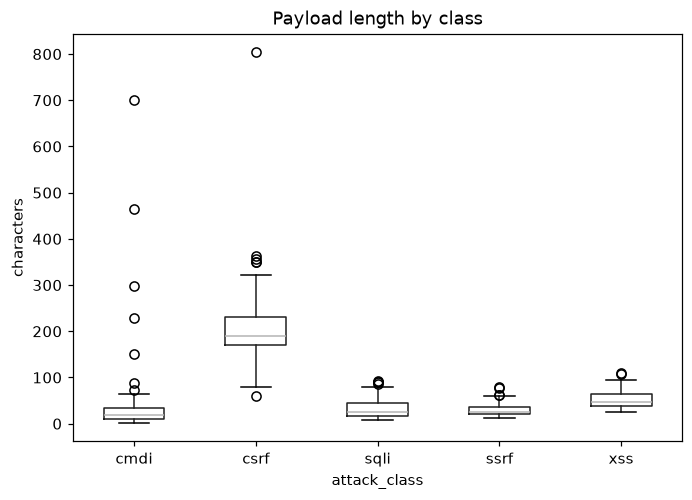

Characteristic substrings present per class (share of that class):
  sqli : {'--': ' 79%', "'": ' 99%', 'UNION': ' 10%', 'SLEEP': ' 30%', 'OR ': ' 66%'}
  xss  : {'<script': ' 15%', 'onerror': '  4%', 'alert': ' 98%', '<img': '  1%', 'javascript:': ' 16%'}
  cmdi : {';': ' 58%', '|': ' 11%', '$(': ' 14%', '`': '  1%', '&&': '  8%'}
  ssrf : {'http://': ' 55%', '127.0.0.1': ' 68%', 'localhost': '  0%', 'file://': '  4%', '169.254': '  2%'}
  csrf : {'<form': ' 55%', 'action=': ' 69%', '<img': '  7%', 'method=': ' 67%', 'token': '  3%'}


In [25]:
df["payload_len"] = df["payload"].str.len()
df.boxplot(column="payload_len", by="attack_class", grid=False)
plt.title("Payload length by class"); plt.suptitle(""); plt.ylabel("characters")
plt.tight_layout(); plt.show()

signals = {"sqli": ["--", "'", "UNION", "SLEEP", "OR "],
           "xss": ["<script", "onerror", "alert", "<img", "javascript:"],
           "cmdi": [";", "|", "$(", "`", "&&"],
           "ssrf": ["http://", "127.0.0.1", "localhost", "file://", "169.254"],
           "csrf": ["<form", "action=", "<img", "method=", "token"]}
print("Characteristic substrings present per class (share of that class):")
for cls, toks in signals.items():
    sub = df[df.attack_class == cls]
    row = {t: f"{sub.payload.str.contains(re.escape(t), case=False).mean()*100:3.0f}%" for t in toks}
    print(f"  {cls:5s}: {row}")

## 7. Baseline model — char n-gram TF-IDF + Logistic Regression  *(week-2)*

Chosen because it is **inherently interpretable**: a linear model over TF-IDF lets
us read off exactly which patterns drive each class (Section 8), so the XAI is
faithful rather than post-hoc. Task: payload → `attack_class`, stratified split +
5-fold CV.

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

X = df["payload"].values
y = df["attack_class"].values

model = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), min_df=2)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                               random_state=RANDOM_STATE)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_f1 = cross_val_score(model, X, y, cv=cv, scoring="f1_macro")
print(f"5-fold CV macro-F1: {cv_f1.mean():.3f} +/- {cv_f1.std():.3f}")
print("per-fold:", np.round(cv_f1, 3))

5-fold CV macro-F1: 0.975 +/- 0.012
per-fold: [0.953 0.976 0.977 0.979 0.989]


### 7.1 Held-out evaluation (per-class precision / recall)

              precision    recall  f1-score   support

        cmdi      1.000     0.955     0.977        22
        csrf      1.000     1.000     1.000        24
        sqli      1.000     1.000     1.000        22
        ssrf      0.955     1.000     0.977        21
         xss      1.000     1.000     1.000        25

    accuracy                          0.991       114
   macro avg      0.991     0.991     0.991       114
weighted avg      0.992     0.991     0.991       114



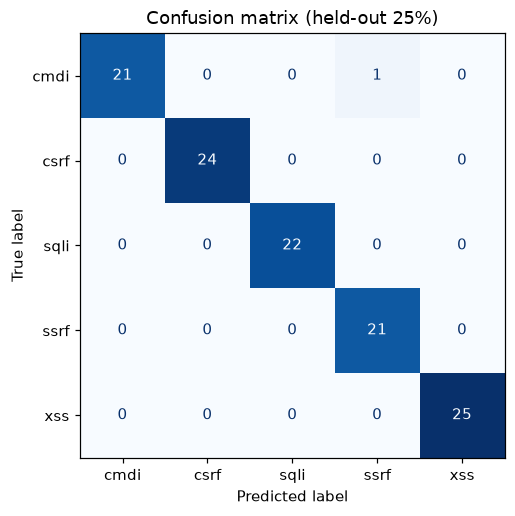

Refit on all 455 rows. Vocab: 6424 n-grams; classes: ['cmdi', 'csrf', 'sqli', 'ssrf', 'xss']


In [27]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
model.fit(X_tr, y_tr)
y_pred = model.predict(X_te)
print(classification_report(y_te, y_pred, digits=3))

labels = sorted(np.unique(y))
cm = confusion_matrix(y_te, y_pred, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues", colorbar=False)
plt.title("Confusion matrix (held-out 25%)"); plt.tight_layout(); plt.show()

# Refit on all data for interpretation + demos below.
model.fit(X, y)
vec = model.named_steps["tfidf"]; clf = model.named_steps["clf"]
feature_names = np.array(vec.get_feature_names_out())
print(f"Refit on all {len(X)} rows. Vocab: {len(feature_names)} n-grams; "
      f"classes: {list(clf.classes_)}")

**Read this score honestly.** ~0.97+ macro-F1 is *expected*, not impressive:
the canonical payloads are syntactically very distinct, so the task is easy. The
informative result is Section 10, where trivial obfuscation collapses this
confidence — that gap, not the headline score, is the finding.

## 8. Explainability (XAI)  *(week-2)*

For a linear model the explanation is **exact**: coefficients *are* the model
(global), and a single prediction decomposes as `tfidf_value × coefficient` per
feature (local). LIME/SHAP are the model-agnostic alternatives you'd use for a
non-linear model; here the exact decomposition is strictly more faithful.

### 8.1 Global — top character patterns per class

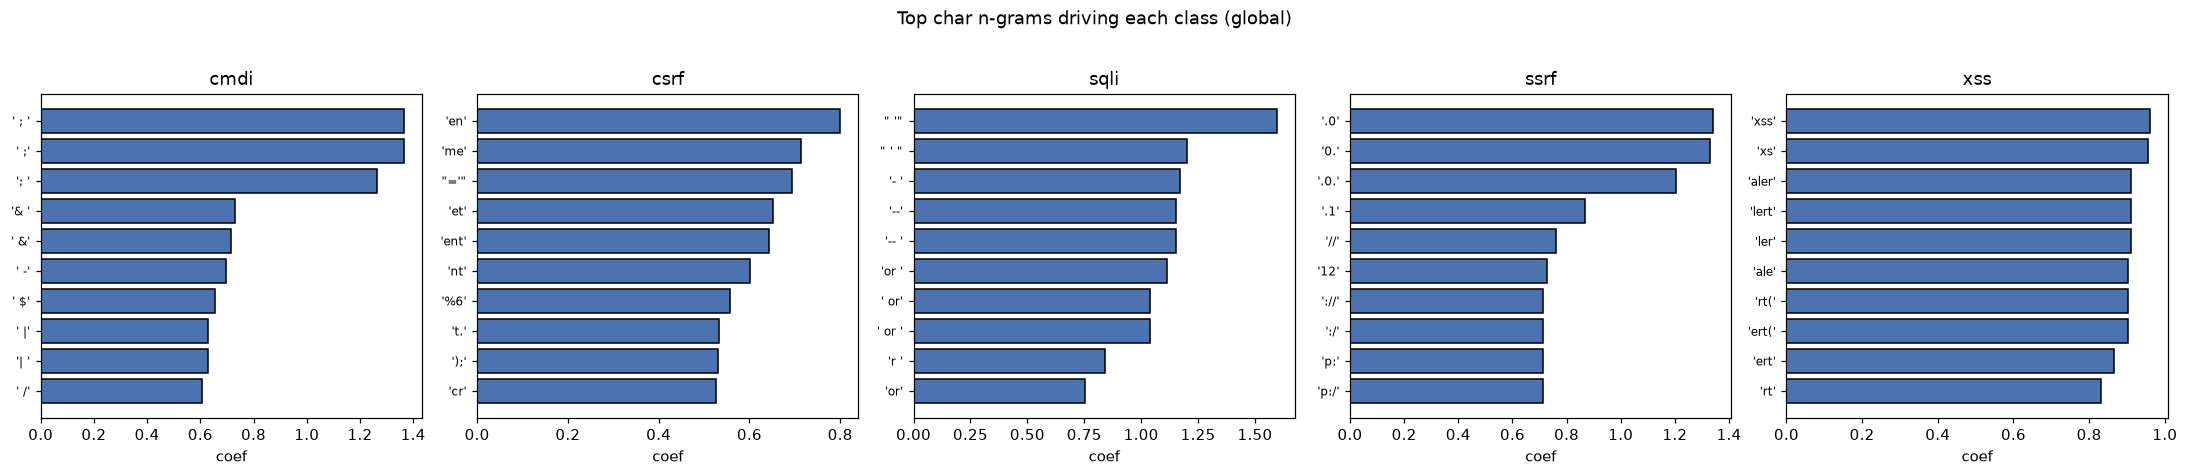

In [28]:
def top_features_for_class(ci, n=10):
    coefs = clf.coef_[ci]; top = np.argsort(coefs)[-n:][::-1]
    return feature_names[top], coefs[top]

fig, axes = plt.subplots(1, len(clf.classes_), figsize=(4*len(clf.classes_), 4.2))
for ax, ci in zip(axes, range(len(clf.classes_))):
    names, vals = top_features_for_class(ci)
    ax.barh(range(len(vals))[::-1], vals, color="#4C72B0", edgecolor="black")
    ax.set_yticks(range(len(names))[::-1]); ax.set_yticklabels([repr(s) for s in names], fontsize=8)
    ax.set_title(clf.classes_[ci]); ax.set_xlabel("coef")
fig.suptitle("Top char n-grams driving each class (global)", y=1.02)
plt.tight_layout(); plt.show()

### 8.2 Local — exact contribution decomposition for one payload

In [29]:
def explain_local(payload, top_n=10):
    x = vec.transform([payload]); pred = model.predict([payload])[0]
    ci = list(clf.classes_).index(pred)
    contrib = x.multiply(clf.coef_[ci]).toarray().ravel()
    proba = model.predict_proba([payload])[0]
    print(f"Payload  : {payload!r}")
    print(f"Predicted: {pred}  (p={proba[ci]:.3f})")
    for idx in np.argsort(contrib)[-top_n:][::-1]:
        if contrib[idx] > 0:
            print(f"   {feature_names[idx]!r:>10} -> +{contrib[idx]:.3f}")

for p in ["' OR '1'='1", "<script>alert(1)</script>", "; cat /etc/passwd",
          "http://169.254.169.254/latest/meta-data/"]:
    explain_local(p); print("-" * 60)

Payload  : "' OR '1'='1"
Predicted: sqli  (p=0.721)
         " '" -> +0.463
        " ' " -> +0.201
        'or ' -> +0.193
       ' or ' -> +0.189
        ' or' -> +0.189
         'r ' -> +0.127
         'or' -> +0.087
         "' " -> +0.080
         ' o' -> +0.075
        "'='" -> +0.068
------------------------------------------------------------
Payload  : '<script>alert(1)</script>'
Predicted: xss  (p=0.691)
       'lert' -> +0.083
       'aler' -> +0.083
        'ler' -> +0.083
       'ert(' -> +0.083
        'rt(' -> +0.083
        'ale' -> +0.082
        'ert' -> +0.077
         'rt' -> +0.071
       'ript' -> +0.052
        'rip' -> +0.052
------------------------------------------------------------
Payload  : '; cat /etc/passwd'
Predicted: cmdi  (p=0.677)
        ' ; ' -> +0.156
         ' ;' -> +0.156
         '; ' -> +0.130
         ' /' -> +0.097
        'at ' -> +0.061
         'd ' -> +0.051
       'cat ' -> +0.051
       ' /et' -> +0.051
        ' /e' -> +0.051
       

## 9. Risk assessment (NIST AI RMF: Map → Measure → Manage)  *(week-2)*

| # | Risk (Map) | Detect (Measure) | Treatment / example (Manage) |
|---|-----------|------------------|------------------------------|
| 1 | **No-benign-class validity gap** — never sees benign input, labels everything as an attack. | Feed benign strings; observe confident misclassification (10.2). | Never expose as a "malicious?" gate. Documented out-of-scope in the model card; add a benign class before any such use. |
| 2 | **Obfuscation evasion (adversarial)** — canonical strings trivially altered. | Apply transforms, measure confidence drop / flips (10.1). | Treat output as a *soft prior*; confirmation stays with detection oracles; optionally augment training with obfuscated variants. |
| 3 | **Superficial-feature bias** — n-grams may key on incidental tokens. | Inspect global coefficients (8.1). | Keep the model interpretable so spurious features are visible; prune via `min_df`; review each retrain. |
| 4 | **Class / context imbalance** — mild imbalance, uneven bucket coverage. | Class shares (§1), repaired coverage (4.1). | `class_weight='balanced'`; report per-class recall; flag blind-spot buckets to fairness. |
| 5 | **Automation bias / over-reliance** — humans trusting a confident label. | Process risk. | Layer-5 human review; every prediction ships with probability + explanation, never a bare verdict. |
| 6 | **Dual-use** — an attack classifier is offensive knowledge. | Purpose + scope documented. | Sandbox-only allowlist, audit log, defensive-research framing (StGB §202c). |

## 10. Limitations, biases & attacks — demonstrated  *(week-2)*

### 10.1 Attack: obfuscation evasion

Canonical payloads, label-preserving obfuscations, watch confidence fall / labels
flip — the reason model output must stay a soft prior.

In [30]:
def obfuscate(payload):
    return {
        "upper/mixed case": payload.swapcase(),
        "url-encoded": "".join(f"%{ord(c):02X}" if not c.isalnum() else c for c in payload),
        "inline comment": payload.replace(" ", "/**/") if " " in payload else payload + "/**/",
        "whitespace pad": payload.replace(" ", "  \t "),
    }

def confidence(payload):
    proba = model.predict_proba([payload])[0]
    return clf.classes_[np.argmax(proba)], proba.max()

for payload in ["' OR '1'='1", "<script>alert(1)</script>", "; cat /etc/passwd"]:
    bp, bc = confidence(payload)
    print(f"\nBASE  {payload!r} -> {bp} (conf {bc:.3f})")
    for name, variant in obfuscate(payload).items():
        p, c = confidence(variant)
        flag = "  <-- FLIPPED" if p != bp else ""
        print(f"  {name:16s} -> {p:5s} (conf {c:.3f}, drop {bc-c:+.3f}){flag}")


BASE  "' OR '1'='1" -> sqli (conf 0.721)
  upper/mixed case -> sqli  (conf 0.721, drop +0.000)
  url-encoded      -> ssrf  (conf 0.333, drop +0.388)  <-- FLIPPED
  inline comment   -> sqli  (conf 0.362, drop +0.358)
  whitespace pad   -> sqli  (conf 0.721, drop +0.000)

BASE  '<script>alert(1)</script>' -> xss (conf 0.691)
  upper/mixed case -> xss   (conf 0.691, drop +0.000)
  url-encoded      -> xss   (conf 0.398, drop +0.292)
  inline comment   -> xss   (conf 0.670, drop +0.021)
  whitespace pad   -> xss   (conf 0.691, drop +0.000)

BASE  '; cat /etc/passwd' -> cmdi (conf 0.677)
  upper/mixed case -> cmdi  (conf 0.677, drop +0.000)
  url-encoded      -> cmdi  (conf 0.402, drop +0.276)
  inline comment   -> cmdi  (conf 0.405, drop +0.272)
  whitespace pad   -> cmdi  (conf 0.677, drop +0.000)


### 10.2 Bias / limitation: the no-benign-class gap

Benign strings are still forced into an attack class, often confidently. Any use
as a maliciousness gate would be invalid.

In [31]:
benign = ["hello world", "john.doe@example.com", "I love this product!",
          "2024-01-15", "SELECT your favourite colour", "search for red shoes"]
print(f"{'input':38s} {'predicted':8s} confidence")
print("-" * 60)
for s in benign:
    pred, conf = confidence(s)
    print(f"{s!r:38s} {pred:8s} {conf:.3f}")
print("\nEvery benign string is confidently labelled an attack -> gap demonstrated.")

input                                  predicted confidence
------------------------------------------------------------
'hello world'                          cmdi     0.378
'john.doe@example.com'                 cmdi     0.337
'I love this product!'                 cmdi     0.434
'2024-01-15'                           cmdi     0.363
'SELECT your favourite colour'         sqli     0.370
'search for red shoes'                 cmdi     0.362

Every benign string is confidently labelled an attack -> gap demonstrated.


## 11. Pseudo-model-card

**Model:** Payload Attack-Class Classifier (baseline) · v0.1
**Owner:** Offensive IT-Tester group · Responsible AI & Data Ethics

**Details** — `TfidfVectorizer(char_wb, 2–4-grams)` → `LogisticRegression(class_weight='balanced')` (scikit-learn Pipeline). Input: one payload string. Output: one of `{sqli, xss, csrf, cmdi, ssrf}` + probabilities. Deliberately linear for interpretability.

**Intended use** — a *soft prior* to triage/route payloads (Layer 3) and hint Layer 6. Always paired with a probability + explanation, always under human review.

**Out-of-scope / prohibited**
- ❌ As an "is this input malicious?" detector — **no benign class** (§10.2).
- ❌ As proof a target is vulnerable — that is the detection oracles' job.
- ❌ Against any target not on the sandbox allowlist.

**Training data** — `payloads_clean.jsonl`, 455 attack payloads, 5 classes (~19–22% each), attack-only (no benign). Context normalised to injection-point buckets (§3.1).

**Metrics** — 5-fold CV macro-F1 and held-out per-class precision/recall computed live in §7. Report per-class recall, not just accuracy.

**Ethical & legal** — dual-use; lawfulness rests on sandbox-only scope, audit logging, defensive intent (StGB §202a–c). GDPR: payload strings only, no personal data (data minimisation).

**Known limitations, biases & attacks**
- No-benign-class validity gap (headline).
- Obfuscation-evasion drops confidence / flips labels (§10.1).
- `context` semantics are class-dependent (§3.1) → selection must be class-aware.
- Possible superficial-feature reliance; mitigated by interpretability.
- Mild class imbalance; uneven injection-point coverage (§4.1).

**Maintenance** — on each retrain: review global top-features, re-run the evasion demo, expand `BUCKET_RULES` for new contexts; revisit when a benign class is added.

---
*End of notebook — every result above is produced by running the cells in order.*